In [1]:
# تثبيت المكتبات المطلوبة لبناء النموذج وتحليل البيانات وعرض الرسوم البيانية
%pip install -q tensorflow scikit-learn matplotlib seaborn pandas

In [2]:
# استيراد المكتبات الأساسية وضبط البذور العشوائية للحصول على نتائج قابلة للتكرار
import json, random, math, re
from collections import Counter
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  نموذج نبّهني للعادات v2: نموذج ثنائي المخرجات يدعم العربية والإنجليزية
# ══════════════════════════════════════════════════════════════════════════════
#
#  المدخلات: تمثيل اليوم والساعة بشكل دائري مع مؤشرات الكلمات المفتاحية
#  المخرجات: رأس لتصنيف الفئة ورأس لتحديد نوع الموقع المتوقع
#
#  بيانات التدريب:
#    - قوالب عربية وإنجليزية تحتوي على عنوان المهمة والفئة والموقع والوقت المتوقع.
#    - يمكن إضافة بيانات MS-LaTTE اختياريًا لتحسين تنوع عناوين المهام الإنجليزية.
# ══════════════════════════════════════════════════════════════════════════════

# تعريف الفئات الأساسية التي يتعلم النموذج تصنيف التذكير إليها
CATEGORIES = ["personal", "work", "family", "other"]
CAT_IDX    = {c: i for i, c in enumerate(CATEGORIES)}

# تعريف أنواع المواقع التي يمكن للنموذج توقعها لكل تذكير
LOCATION_TYPES = [
    "none",        # لا يوجد موقع واضح مرتبط بالتذكير
    "pharmacy",
    "grocery",
    "work",
    "home",
    "gym",
    "hospital",
    "bank",
    "store",
    "restaurant",
    "cafe",
    "school",
    "mosque",
]
LOC_IDX = {c: i for i, c in enumerate(LOCATION_TYPES)}

# بناء قاموس الكلمات المفتاحية العربية والإنجليزية التي تتحول إلى خصائص رقمية للنموذج
VOCAB_SET = {
    # كلمات إنجليزية عامة تساعد على فهم نوع المهمة أو مكانها
    "appointment", "bank", "birthday", "buy", "call", "car", "clean",
    "collect", "cook", "deadline", "dinner", "doctor", "email",
    "errand", "exam", "exercise", "family", "fix", "gather",
    "groceries", "gym", "homework", "hospital", "journal", "kids",
    "laundry", "lecture", "lunch", "medication", "meditation",
    "meeting", "pay", "pharmacy", "pickup", "picnic",
    "presentation", "project", "report", "return", "review",
    "school", "shopping", "skincare", "store", "study", "submit", "task",
    "visit", "vitamins",
    # كلمات إنجليزية مرتبطة بالأماكن والأنشطة اليومية
    "cafe", "coffee", "restaurant", "mosque", "friday", "jumah",
    "salon", "barber", "tailor", "post", "airport", "park",
    "library", "bookstore", "mall", "clothes", "electronics",
    "bakery", "bread", "milk", "eggs", "vegetables", "fruit",
    # كلمات عربية مطابقة كما هي بدون اشتقاق أو تجذير
    "نادي", "صالة", "رياضة", "جيم",
    "صيدلية", "دواء", "مستشفى", "طبيب", "عيادة",
    "خبز", "حليب", "بيض", "سوق", "بقالة", "سوبرماركت", "محل",
    "مدرسة", "جامعة", "محاضرة", "امتحان", "واجب", "دراسة",
    "اجتماع", "مشروع", "شغل", "عمل", "مكتب",
    "عائلة", "اهل", "اولاد", "اطفال", "ام", "اب", "اخ", "اخت",
    "مطعم", "قهوة", "كافيه",
    "بنك", "مصرف", "صراف", "فاتورة", "دفع",
    "منزل", "بيت",
    "مسجد", "جامع", "جمعة",
    "تسوق", "شراء",
}

# ربط المرادفات بالكلمات الموجودة في القاموس لتفعيل خصائص إضافية بدون استخدامها كتسميات مباشرة
SYNONYMS = {
    # مرادفات إنجليزية توسّع الكلمات المفتاحية عند قراءة عنوان التذكير
    'work':        ['meeting', 'task', 'project'],
    'working':     ['meeting', 'task', 'project'],
    'office':      ['meeting', 'task'],
    'company':     ['meeting', 'task'],
    'job':         ['meeting', 'task'],
    'class':       ['lecture', 'study'],
    'classes':     ['lecture', 'study'],
    'university':  ['lecture', 'study', 'exam'],
    'assignment':  ['homework', 'submit'],
    'thesis':      ['project', 'study'],
    'interview':   ['meeting'],
    'conference':  ['meeting'],
    'seminar':     ['lecture'],
    'tutorial':    ['lecture', 'study'],
    'test':        ['exam'],
    'run':         ['exercise'],
    'running':     ['exercise'],
    'jog':         ['exercise'],
    'jogging':     ['exercise'],
    'workout':     ['exercise', 'gym'],
    'sport':       ['exercise', 'gym'],
    'sports':      ['exercise', 'gym'],
    'swim':        ['exercise'],
    'yoga':        ['exercise', 'meditation'],
    'cycling':     ['exercise'],
    'hiking':      ['exercise'],
    'walking':     ['exercise'],
    'stretching':  ['exercise'],
    'eat':         ['dinner', 'lunch'],
    'eating':      ['dinner', 'lunch'],
    'breakfast':   ['lunch', 'cook'],
    'meal':        ['dinner', 'lunch', 'cook'],
    'cooking':     ['cook'],
    'baking':      ['cook', 'bakery'],
    'recipe':      ['cook'],
    'prepare':     ['cook'],
    'shop':        ['shopping', 'store'],
    'market':      ['groceries', 'store'],
    'supermarket': ['groceries', 'store'],
    'purchase':    ['buy', 'shopping'],
    'order':       ['buy', 'store'],
    'grocery':     ['groceries'],
    'pick':        ['pickup'],
    'package':     ['pickup'],
    'parcel':      ['pickup'],
    'deliver':     ['pickup'],
    'delivery':    ['pickup'],
    'drive':       ['car'],
    'driving':     ['car'],
    'garage':      ['fix', 'car'],
    'repair':      ['fix'],
    'maintenance': ['fix'],
    'medicine':    ['medication', 'pharmacy'],
    'drug':        ['pharmacy'],
    'drugstore':   ['pharmacy'],
    'clinic':      ['doctor', 'hospital'],
    'dentist':     ['doctor', 'appointment'],
    'pill':        ['medication', 'pharmacy'],
    'prescription':['medication', 'pharmacy'],
    'refill':      ['medication', 'pharmacy'],
    'checkup':     ['doctor', 'appointment'],
    'children':    ['kids', 'family'],
    'son':         ['kids', 'family'],
    'daughter':    ['kids', 'family'],
    'wife':        ['family'],
    'husband':     ['family'],
    'parent':      ['family', 'visit'],
    'parents':     ['family', 'visit'],
    'brother':     ['family'],
    'sister':      ['family'],
    'uncle':       ['family'],
    'aunt':        ['family'],
    'cousin':      ['family'],
    'grandma':     ['family', 'visit'],
    'grandpa':     ['family', 'visit'],
    'grandmother': ['family', 'visit'],
    'grandfather': ['family', 'visit'],
    'relatives':   ['family', 'visit'],
    'mom':         ['family', 'call'],
    'dad':         ['family', 'call'],
    'money':       ['pay', 'bank'],
    'payment':     ['pay', 'bank'],
    'bill':        ['pay'],
    'bills':       ['pay'],
    'transfer':    ['bank', 'pay'],
    'atm':         ['bank'],
    'deposit':     ['bank', 'pay'],
    'withdraw':    ['bank'],
    'tax':         ['pay'],
    'rent':        ['pay'],
    'insurance':   ['pay'],
    'cleaning':    ['clean'],
    'tidying':     ['clean'],
    'washing':     ['laundry', 'clean'],
    'ironing':     ['laundry'],
    # مرادفات عربية تفعّل الكلمات العربية والإنجليزية المناسبة في خصائص العنوان
    # هذه الكلمات العربية تُطابق قبل تطبيق الاشتقاق لأن العربية تُستخدم كما هي
    'نادي':       ['نادي', 'gym', 'exercise'],
    'صالة':       ['صالة', 'gym'],
    'رياضة':      ['رياضة', 'exercise', 'gym'],
    'جيم':        ['جيم', 'gym'],
    'صيدلية':     ['صيدلية', 'pharmacy', 'medication'],
    'دواء':       ['دواء', 'medication', 'pharmacy'],
    'مستشفى':    ['مستشفى', 'hospital'],
    'طبيب':       ['طبيب', 'doctor', 'hospital'],
    'عيادة':      ['عيادة', 'doctor', 'hospital'],
    'خبز':        ['خبز', 'groceries', 'bread'],
    'حليب':       ['حليب', 'groceries', 'milk'],
    'بيض':        ['بيض', 'groceries', 'eggs'],
    'سوق':        ['سوق', 'groceries', 'store'],
    'بقالة':      ['بقالة', 'groceries'],
    'سوبرماركت':  ['سوبرماركت', 'groceries'],
    'محل':        ['محل', 'store'],
    'مدرسة':      ['مدرسة', 'school'],
    'جامعة':      ['جامعة', 'school', 'study', 'lecture'],
    'محاضرة':     ['محاضرة', 'lecture', 'study'],
    'امتحان':     ['امتحان', 'exam', 'study'],
    'واجب':       ['واجب', 'homework'],
    'دراسة':      ['دراسة', 'study'],
    'اجتماع':     ['اجتماع', 'meeting'],
    'مشروع':      ['مشروع', 'project'],
    'شغل':        ['شغل', 'work', 'task'],
    'عمل':        ['عمل', 'work', 'task'],
    'مكتب':       ['مكتب', 'work'],
    'عائلة':      ['عائلة', 'family'],
    'اهل':        ['اهل', 'family'],
    'اولاد':      ['اولاد', 'kids', 'family'],
    'اطفال':      ['اطفال', 'kids', 'family'],
    'ام':         ['ام', 'family'],
    'اب':         ['اب', 'family'],
    'اخ':         ['اخ', 'family'],
    'اخت':        ['اخت', 'family'],
    'مطعم':       ['مطعم', 'restaurant'],
    'قهوة':       ['قهوة', 'cafe', 'coffee'],
    'كافيه':      ['كافيه', 'cafe', 'coffee'],
    'بنك':        ['بنك', 'bank'],
    'مصرف':       ['مصرف', 'bank'],
    'صراف':       ['صراف', 'bank'],
    'فاتورة':     ['فاتورة', 'pay'],
    'دفع':        ['دفع', 'pay'],
    'منزل':       ['منزل', 'home'],
    'بيت':        ['بيت', 'home'],
    'مسجد':       ['مسجد', 'mosque'],
    'جامع':       ['جامع', 'mosque'],
    'جمعة':       ['جمعة', 'friday', 'mosque'],
    'تسوق':       ['تسوق', 'shopping'],
    'شراء':       ['شراء', 'buy', 'shopping'],
}

# تجهيز محلل النصوص والاشتقاق البسيط للكلمات الإنجليزية مع إبقاء الكلمات العربية كما هي
ARABIC_RANGE = re.compile(r"[\u0600-\u06FF]+")

def is_arabic(word):
    return bool(ARABIC_RANGE.fullmatch(word))

def stem(word):
    if is_arabic(word) or len(word) <= 3:
        return word
    if word.endswith('ies') and len(word) > 4:
        return word[:-3] + 'y'
    if word.endswith('ing') and len(word) > 5:
        return word[:-3]
    if word.endswith('ed') and len(word) > 4:
        return word[:-2]
    if word.endswith('s') and not word.endswith('ss') and len(word) > 3:
        return word[:-1]
    return word

TOKEN_RE = re.compile(r"[a-z\u0600-\u06FF]+")

def tokenize(text):
    return TOKEN_RE.findall(text.lower())

def get_activated_keywords(title):
    """تفعيل كلمات القاموس من العنوان عبر المطابقة المباشرة ثم المرادفات ثم الاشتقاق."""
    activated = set()
    for w in tokenize(title):
        if w in VOCAB_SET:
            activated.add(w); continue
        syns = SYNONYMS.get(w)
        if syns:
            for s in syns:
                if s in VOCAB_SET: activated.add(s)
            continue
        s = stem(w)
        if s in VOCAB_SET:
            activated.add(s); continue
        stem_syns = SYNONYMS.get(s)
        if stem_syns:
            for ss in stem_syns:
                if ss in VOCAB_SET: activated.add(ss)
    return activated

# ══════════════════════════════════════════════════════════════════════════════
#  قوالب التدريب: كل صف يحتوي على العنوان والفئة ونوع الموقع ونطاق الساعة وانحياز اليوم
#  قيم انحياز اليوم: أي يوم، أيام العمل، نهاية الأسبوع، أو يوم الجمعة فقط
# ══════════════════════════════════════════════════════════════════════════════
TEMPLATES = [
    # أمثلة للمهام الشخصية بدون تضمين الصلوات ضمن هذه الفئة
    ("morning exercise",         "personal", "gym",      ( 5.0,  8.0), "any"),
    ("evening workout",          "personal", "gym",      (17.0, 21.0), "any"),
    ("exercise",                 "personal", "gym",      ( 5.0, 21.0), "any"),
    ("go to the gym",            "personal", "gym",      ( 5.0, 21.0), "any"),
    ("gym session",              "personal", "gym",      ( 5.0, 21.0), "any"),
    ("gym workout",              "personal", "gym",      ( 5.0, 21.0), "any"),
    ("morning jog",              "personal", "gym",      ( 5.0,  8.0), "any"),
    ("go running",               "personal", "gym",      ( 5.0, 20.0), "any"),
    ("yoga session",             "personal", "gym",      ( 6.0, 21.0), "any"),
    ("swim practice",            "personal", "gym",      ( 6.0, 21.0), "any"),
    ("morning meditation",       "personal", "home",     ( 5.0,  8.0), "any"),
    ("evening meditation",       "personal", "home",     (19.0, 23.0), "any"),
    ("meditation",               "personal", "home",     ( 5.0, 23.0), "any"),
    ("journal writing",          "personal", "home",     (19.0, 23.0), "any"),
    ("write journal",            "personal", "home",     (19.0, 23.0), "any"),
    ("skincare routine",         "personal", "home",     ( 6.0,  9.0), "any"),
    ("evening skincare",         "personal", "home",     (20.0, 23.0), "any"),
    ("take vitamins",            "personal", "home",     ( 6.0,  9.0), "any"),
    ("take medication",          "personal", "home",     ( 6.0, 22.0), "any"),
    ("medication reminder",      "personal", "home",     ( 6.0, 22.0), "any"),
    ("doctor appointment",       "personal", "hospital", ( 8.0, 16.0), "WD"),
    ("visit doctor",             "personal", "hospital", ( 8.0, 16.0), "WD"),
    ("hospital checkup",         "personal", "hospital", ( 8.0, 16.0), "WD"),
    ("dentist appointment",      "personal", "hospital", ( 8.0, 16.0), "WD"),
    ("clean house",              "personal", "home",     ( 8.0, 14.0), "any"),
    ("clean kitchen",            "personal", "home",     ( 8.0, 14.0), "any"),
    ("clean room",               "personal", "home",     ( 8.0, 18.0), "any"),
    ("do laundry",               "personal", "home",     ( 8.0, 12.0), "any"),
    ("cook dinner",              "personal", "home",     (16.0, 19.0), "any"),
    ("cook lunch",               "personal", "home",     (10.0, 13.0), "any"),
    ("haircut",                  "personal", "store",    (10.0, 20.0), "any"),
    ("barber appointment",       "personal", "store",    (10.0, 20.0), "any"),
    ("salon appointment",        "personal", "store",    (10.0, 20.0), "any"),
    # أمثلة عربية للمهام الشخصية
    ("اذهب الى النادي",           "personal", "gym",      (16.0, 22.0), "any"),
    ("نادي رياضي",                "personal", "gym",      ( 6.0, 21.0), "any"),
    ("تمرين صباحي",               "personal", "gym",      ( 5.0,  8.0), "any"),
    ("موعد الطبيب",               "personal", "hospital", ( 8.0, 16.0), "WD"),
    ("زيارة المستشفى",            "personal", "hospital", ( 8.0, 16.0), "WD"),
    ("الذهاب للصيدلية",           "personal", "pharmacy", ( 8.0, 20.0), "any"),
    ("شراء دواء",                 "personal", "pharmacy", ( 8.0, 20.0), "any"),
    ("تنظيف المنزل",              "personal", "home",     ( 8.0, 14.0), "any"),
    ("طبخ العشاء",                "personal", "home",     (16.0, 19.0), "any"),

    # أمثلة للمهام المرتبطة بالعمل والدراسة
    ("team meeting",             "work",     "work",     ( 8.0, 12.0), "WD"),
    ("meeting with manager",     "work",     "work",     ( 8.0, 17.0), "WD"),
    ("project meeting",          "work",     "work",     ( 8.0, 17.0), "WD"),
    ("meeting",                  "work",     "work",     ( 8.0, 17.0), "WD"),
    ("finish report",            "work",     "work",     ( 8.0, 17.0), "WD"),
    ("write report",             "work",     "work",     ( 8.0, 17.0), "WD"),
    ("submit report",            "work",     "work",     ( 8.0, 17.0), "WD"),
    ("send email",               "work",     "work",     ( 8.0, 18.0), "any"),
    ("review code",              "work",     "work",     ( 8.0, 17.0), "WD"),
    ("review task",              "work",     "work",     ( 8.0, 17.0), "WD"),
    ("prepare presentation",     "work",     "work",     ( 8.0, 17.0), "WD"),
    ("present at meeting",       "work",     "work",     ( 8.0, 17.0), "WD"),
    ("work on project",          "work",     "work",     ( 8.0, 18.0), "any"),
    ("complete task",            "work",     "work",     ( 8.0, 18.0), "any"),
    ("project deadline",         "work",     "work",     ( 8.0, 23.0), "any"),
    ("go to office",             "work",     "work",     ( 7.0,  9.0), "WD"),
    # تُعامل المهام الأكاديمية كجزء من فئة العمل لأنها تعتمد على الإنجاز والمواعيد
    ("attend lecture",           "work",     "school",   ( 8.0, 16.0), "WD"),
    ("lecture today",            "work",     "school",   ( 8.0, 16.0), "WD"),
    ("study for exam",           "work",     "school",   ( 8.0, 23.0), "any"),
    ("study session",            "work",     "school",   ( 8.0, 23.0), "any"),
    ("exam preparation",         "work",     "school",   ( 8.0, 23.0), "any"),
    ("final exam",               "work",     "school",   ( 8.0, 14.0), "WD"),
    ("submit assignment",        "work",     "school",   ( 8.0, 23.0), "any"),
    ("submit homework",          "work",     "school",   ( 8.0, 23.0), "any"),
    ("do homework",              "work",     "school",   (14.0, 23.0), "any"),
    ("go to school",             "work",     "school",   ( 6.0,  8.0), "WD"),
    ("go to university",         "work",     "school",   ( 7.0,  9.0), "WD"),
    ("library study",            "work",     "school",   ( 9.0, 21.0), "any"),
    # أمثلة عربية للمهام المرتبطة بالعمل والدراسة
    ("اجتماع العمل",              "work",     "work",     ( 8.0, 17.0), "WD"),
    ("اجتماع الفريق",             "work",     "work",     ( 8.0, 12.0), "WD"),
    ("ارسال ايميل",               "work",     "work",     ( 8.0, 18.0), "any"),
    ("تسليم التقرير",             "work",     "work",     ( 8.0, 17.0), "WD"),
    ("مشروع التخرج",              "work",     "school",   ( 8.0, 23.0), "any"),
    ("محاضرة اليوم",              "work",     "school",   ( 8.0, 16.0), "WD"),
    ("مراجعة للامتحان",           "work",     "school",   ( 8.0, 23.0), "any"),
    ("تسليم الواجب",              "work",     "school",   ( 8.0, 23.0), "any"),
    ("الذهاب للمدرسة",            "work",     "school",   ( 6.0,  8.0), "WD"),
    ("الذهاب للجامعة",            "work",     "school",   ( 7.0,  9.0), "WD"),

    # أمثلة للمهام العائلية
    ("dinner with family",       "family",   "home",     (18.0, 21.0), "any"),
    ("family dinner",            "family",   "home",     (18.0, 21.0), "any"),
    ("family gathering",         "family",   "home",     (14.0, 22.0), "WE"),
    ("family time",              "family",   "home",     (16.0, 22.0), "any"),
    ("family event",             "family",   "home",     (10.0, 22.0), "WE"),
    ("take kids to park",        "family",   "none",     (15.0, 18.0), "any"),
    ("kids activities",          "family",   "home",     (14.0, 20.0), "any"),
    ("play with kids",           "family",   "home",     (14.0, 20.0), "any"),
    ("pick up kids",             "family",   "school",   (12.0, 16.0), "WD"),
    ("visit parents",            "family",   "none",     (14.0, 21.0), "any"),
    ("visit grandma",            "family",   "none",     (14.0, 21.0), "any"),
    ("visit family",             "family",   "none",     (10.0, 21.0), "WE"),
    ("family picnic",            "family",   "none",     ( 9.0, 14.0), "WE"),
    ("birthday party",           "family",   "home",     (14.0, 22.0), "any"),
    ("birthday celebration",     "family",   "home",     (14.0, 22.0), "any"),
    ("call mom",                 "family",   "none",     ( 9.0, 22.0), "any"),
    ("call dad",                 "family",   "none",     ( 9.0, 22.0), "any"),
    ("call parents",             "family",   "none",     ( 9.0, 22.0), "any"),
    ("family at restaurant",     "family",   "restaurant",(18.0, 22.0), "WE"),
    # أمثلة عربية للمهام العائلية
    ("عشاء مع العائلة",           "family",   "home",     (18.0, 21.0), "any"),
    ("زيارة الاهل",               "family",   "none",     (10.0, 21.0), "WE"),
    ("لعب مع الاطفال",            "family",   "home",     (14.0, 20.0), "any"),
    ("اخذ الاولاد للمدرسة",       "family",   "school",   ( 6.0,  8.0), "WD"),
    ("احضار الاولاد من المدرسة",  "family",   "school",   (12.0, 16.0), "WD"),
    ("حفلة عيد ميلاد",            "family",   "home",     (14.0, 22.0), "any"),
    ("اتصال بالام",               "family",   "none",     ( 9.0, 22.0), "any"),

    # أمثلة للمهام الأخرى مثل التسوق والمشاوير والخدمات المالية
    ("buy groceries",            "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("grocery shopping",         "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("buy milk",                 "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("buy bread",                "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("buy eggs",                 "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("buy vegetables",           "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("buy fruit",                "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("go to the bakery",         "other",    "grocery",  ( 7.0, 20.0), "any"),
    ("go shopping",              "other",    "store",    (10.0, 21.0), "any"),
    ("shopping mall",            "other",    "store",    (10.0, 22.0), "any"),
    ("buy clothes",              "other",    "store",    (10.0, 21.0), "any"),
    ("buy electronics",          "other",    "store",    (10.0, 21.0), "any"),
    ("bookstore",                "other",    "store",    (10.0, 21.0), "any"),
    ("pick up package",          "other",    "none",     ( 9.0, 19.0), "any"),
    ("pick up parcel",           "other",    "none",     ( 9.0, 19.0), "any"),
    ("pay bills",                "other",    "bank",     ( 8.0, 17.0), "WD"),
    ("pay rent",                 "other",    "bank",     ( 8.0, 17.0), "WD"),
    ("go to the bank",           "other",    "bank",     ( 9.0, 15.0), "WD"),
    ("bank transfer",            "other",    "bank",     ( 9.0, 16.0), "WD"),
    ("atm withdrawal",           "other",    "bank",     ( 7.0, 23.0), "any"),
    ("go to pharmacy",           "other",    "pharmacy", ( 8.0, 22.0), "any"),
    ("pharmacy errand",          "other",    "pharmacy", ( 8.0, 22.0), "any"),
    ("return items",             "other",    "store",    ( 9.0, 20.0), "any"),
    ("return to store",          "other",    "store",    ( 9.0, 20.0), "any"),
    ("run errands",              "other",    "none",     ( 8.0, 19.0), "any"),
    ("collect package",          "other",    "none",     ( 9.0, 19.0), "any"),
    ("car service",              "other",    "none",     ( 8.0, 17.0), "WD"),
    ("car wash",                 "other",    "none",     ( 8.0, 19.0), "any"),
    ("lunch at restaurant",      "other",    "restaurant",(12.0, 15.0), "any"),
    ("dinner at restaurant",     "other",    "restaurant",(18.0, 22.0), "any"),
    ("coffee with friend",       "other",    "cafe",     ( 9.0, 22.0), "any"),
    ("morning coffee",           "other",    "cafe",     ( 7.0, 11.0), "any"),
    ("meet friend at cafe",      "other",    "cafe",     ( 9.0, 22.0), "any"),
    ("jumah at mosque",          "other",    "mosque",   (12.0, 14.0), "FRI"),
    ("friday prayer",            "other",    "mosque",   (12.0, 14.0), "FRI"),
    # أمثلة عربية للمهام الأخرى
    ("شراء بقالة",                "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("شراء خبز",                  "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("شراء حليب",                 "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("الذهاب للسوق",              "other",    "grocery",  ( 9.0, 21.0), "any"),
    ("تسوق",                      "other",    "store",    (10.0, 22.0), "any"),
    ("الذهاب للبنك",              "other",    "bank",     ( 9.0, 15.0), "WD"),
    ("دفع الفاتورة",              "other",    "bank",     ( 8.0, 17.0), "WD"),
    ("الذهاب للمطعم",             "other",    "restaurant",(12.0, 22.0), "any"),
    ("قهوة الصباح",               "other",    "cafe",     ( 7.0, 11.0), "any"),
    ("كافيه مع صديق",             "other",    "cafe",     ( 9.0, 22.0), "any"),
    ("صلاة الجمعة",               "other",    "mosque",   (12.0, 14.0), "FRI"),
    ("الذهاب للمسجد",             "other",    "mosque",   ( 4.0, 22.0), "any"),
]

def sample_day(bias):
    # اختيار يوم مناسب حسب الانحياز: أيام العمل في السعودية من الأحد إلى الخميس، والجمعة والسبت نهاية الأسبوع
    if bias == "WD":
        return random.randint(0, 4)
    if bias == "WE":
        return random.choice([5, 6])
    if bias == "FRI":
        return 5
    return random.randint(0, 6)

# توسيع القوالب إلى عينات تدريب كثيرة عبر توليد أيام وساعات عشوائية ضمن النطاق المحدد
TEMPLATE_COPIES = 90
records = []  # كل سجل يحتوي على اليوم والساعة ورقم الفئة ورقم الموقع والعنوان

for title, cat, loc, (h_lo, h_hi), bias in TEMPLATES:
    ci = CAT_IDX[cat]
    li = LOC_IDX[loc]
    for _ in range(TEMPLATE_COPIES):
        day  = sample_day(bias)
        hour = round(random.uniform(h_lo, h_hi), 2)
        records.append((day, hour, ci, li, title))

print(f"From templates: {len(records):,} samples")

# إضافة اختيارية لبيانات MS-LaTTE لتحسين تصنيف الفئة فقط إذا رفع المستخدم الملف في Colab
try:
    from google.colab import files as colab_files
    print("\n📁 Optional: upload MS-LaTTE.json for extra English diversity "
          "(Cancel to skip):")
    uploaded = colab_files.upload()
    if uploaded:
        import io
        raw_data = json.load(io.BytesIO(next(iter(uploaded.values()))))
        print(f"✓ Loaded {len(raw_data)} MS-LaTTE tasks")

        # تحويل كلمات MS-LaTTE المفتاحية إلى فئات تدريب مع استبعاد الكلمات غير المطلوبة
        KEYWORD_TO_CAT = {
            'quran': 'personal', 'exercise': 'personal', 'gym': 'personal',
            'meditation': 'personal', 'journal': 'personal', 'skincare': 'personal',
            'vitamins': 'personal', 'medication': 'personal', 'clean': 'personal',
            'laundry': 'personal', 'cook': 'personal', 'doctor': 'personal',
            'hospital': 'personal',
            'meeting': 'work', 'deadline': 'work', 'report': 'work',
            'presentation': 'work', 'project': 'work', 'email': 'work',
            'exam': 'work', 'study': 'work', 'lecture': 'work',
            'homework': 'work', 'submit': 'work', 'review': 'work',
            'task': 'work', 'school': 'work',
            'family': 'family', 'kids': 'family', 'picnic': 'family',
            'gather': 'family', 'birthday': 'family',
            'groceries': 'other', 'shopping': 'other', 'buy': 'other',
            'store': 'other', 'errand': 'other', 'pickup': 'other',
            'bank': 'other', 'pay': 'other', 'pharmacy': 'other',
            'return': 'other', 'collect': 'other', 'car': 'other',
        }
        TIME_TO_HOUR = {
            "morning": (7, 11), "afternoon": (12, 16),
            "evening": (17, 21), "night": (21, 23), "anytime": (6, 22),
        }
        n_kept = 0
        for entry in raw_data:
            title = entry.get("TaskTitle", "").lower().strip()
            if not title: continue
            kws = get_activated_keywords(title)
            votes = Counter(KEYWORD_TO_CAT[k] for k in kws if k in KEYWORD_TO_CAT)
            if not votes: continue
            top = votes.most_common(2)
            if len(top) > 1 and top[0][1] == top[1][1]: continue
            cat_idx = CAT_IDX[top[0][0]]
            for tj in entry.get("TimeJudgements", []):
                if tj.get("Known") != "yes" or "Times" not in tj: continue
                for tl in tj["Times"].split(","):
                    tl = tl.strip()
                    if "-" not in tl: continue
                    wd_we, period = tl.split("-", 1)
                    day = random.randint(0, 4) if wd_we == "WD" else random.choice([5, 6])
                    lo, hi = TIME_TO_HOUR.get(period, (6, 22))
                    hour = round(random.uniform(lo, hi), 2)
                    records.append((day, hour, cat_idx, LOC_IDX["none"], title))
                    n_kept += 1
        print(f"✓ Added {n_kept:,} MS-LaTTE samples (loc=none, cat head only)")
except Exception as e:
    print(f"(MS-LaTTE skipped: {e})")

# موازنة البيانات حسب أحد مخرجات النموذج لتقليل تحيز التدريب نحو الفئات الأكثر تكرارًا
def balance_by_head(records, head_idx, num_classes):
    buckets = {i: [] for i in range(num_classes)}
    for r in records:
        buckets[r[head_idx]].append(r)
    counts = [len(b) for b in buckets.values()]
    target = max(counts)
    out = []
    for i, bucket in buckets.items():
        if not bucket: continue
        if len(bucket) >= target:
            out.extend(random.sample(bucket, target))
        else:
            out.extend(bucket)
            for _ in range(target - len(bucket)):
                d, h, ci, li, t = random.choice(bucket)
                h2 = max(0.0, min(23.99, h + random.uniform(-1.5, 1.5)))
                if random.random() < 0.25:
                    d = (d + random.choice([-1, 1])) % 7
                out.append((d, round(h2, 2), ci, li, t))
    random.shuffle(out)
    return out

records = balance_by_head(records, head_idx=2, num_classes=len(CATEGORIES))
# عرض توزيع الفئات والمواقع بعد الموازنة لمراجعة جودة بيانات التدريب
# لا تتم موازنة المواقع بشكل كامل لأن بيانات MS-LaTTE تضيف الموقع كقيمة none
loc_counts = Counter(r[3] for r in records)
print(f"\nCategory distribution: {Counter(CATEGORIES[r[2]] for r in records)}")
print(f"Location distribution: {Counter(LOCATION_TYPES[r[3]] for r in records)}")
print(f"Total training samples: {len(records):,}")

From templates: 13,770 samples

📁 Optional: upload MS-LaTTE.json for extra English diversity (Cancel to skip):


Saving MS-LaTTE.json to MS-LaTTE.json
✓ Loaded 10101 MS-LaTTE tasks
✓ Added 30,048 MS-LaTTE samples (loc=none, cat head only)

Category distribution: Counter({'work': 17663, 'other': 17663, 'personal': 17663, 'family': 17663})
Location distribution: Counter({'none': 46670, 'home': 9359, 'school': 3275, 'gym': 2755, 'work': 2070, 'store': 1359, 'hospital': 1298, 'grocery': 1080, 'restaurant': 739, 'bank': 630, 'pharmacy': 607, 'cafe': 450, 'mosque': 360})
Total training samples: 70,652


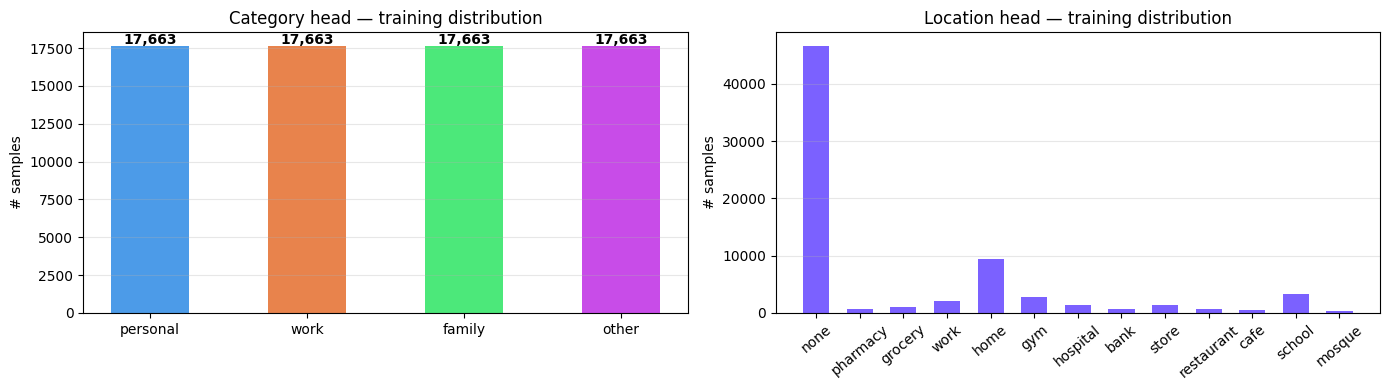

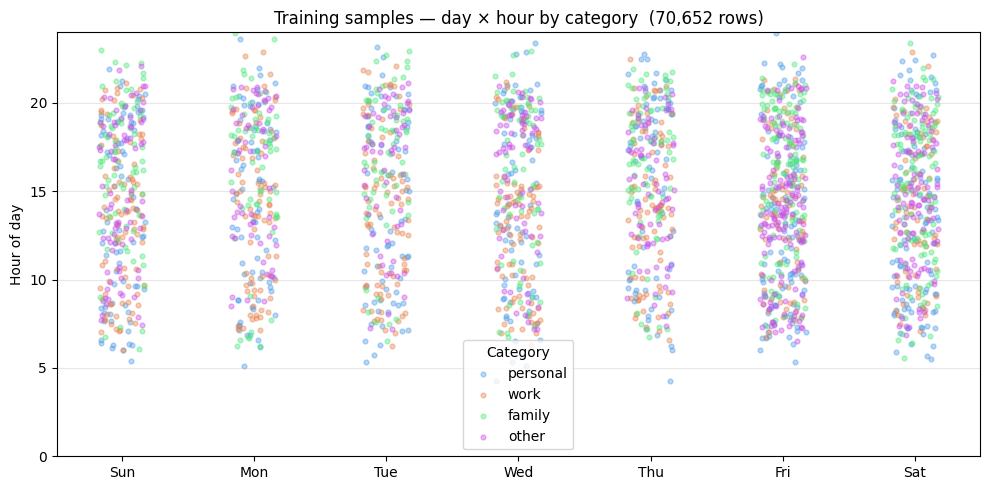

In [4]:
# رسم توزيعات بيانات التدريب لفحص توازن الفئات والمواقع وانتشار العينات عبر الأيام والساعات
import pandas as pd
import matplotlib.pyplot as plt

DAY_NAMES  = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
CAT_COLORS = {"personal": "#4C9BE8", "work": "#E8834C",
              "family":   "#4CE87A", "other": "#C84CE8"}

# عرض عدد عينات التدريب لكل فئة ولكل نوع موقع
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cat_counts = Counter(CATEGORIES[r[2]] for r in records)
cat_vals   = [cat_counts.get(c, 0) for c in CATEGORIES]
bars = axes[0].bar(CATEGORIES, cat_vals,
                   color=[CAT_COLORS[c] for c in CATEGORIES], width=0.5)
for b, v in zip(bars, cat_vals):
    axes[0].text(b.get_x() + b.get_width()/2., v + 100,
                 f"{v:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Category head — training distribution")
axes[0].set_ylabel("# samples")
axes[0].grid(axis="y", alpha=0.3)

loc_counts = Counter(LOCATION_TYPES[r[3]] for r in records)
loc_vals   = [loc_counts.get(l, 0) for l in LOCATION_TYPES]
axes[1].bar(LOCATION_TYPES, loc_vals, color="#7B61FF", width=0.6)
axes[1].set_title("Location head — training distribution")
axes[1].set_ylabel("# samples")
axes[1].tick_params(axis='x', rotation=40)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# رسم علاقة اليوم والساعة مع الفئة للتأكد من أن العينات تغطي أنماطًا زمنية متنوعة
df = pd.DataFrame(records, columns=["day_idx", "hour", "cat_idx", "loc_idx", "title"])
df["category"] = df["cat_idx"].map(lambda c: CATEGORIES[c])

fig, ax = plt.subplots(figsize=(10, 5))
for cat, color in CAT_COLORS.items():
    sub = df[df["category"] == cat]
    s   = sub.sample(min(600, len(sub)))
    ax.scatter(s["day_idx"] + (np.random.rand(len(s)) - 0.5) * 0.35,
               s["hour"], c=color, alpha=0.4, s=12, label=cat)
ax.set_xticks(range(7)); ax.set_xticklabels(DAY_NAMES)
ax.set_ylabel("Hour of day"); ax.set_ylim(0, 24)
ax.set_title(f"Training samples — day × hour by category  ({len(records):,} rows)")
ax.legend(title="Category"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
# تجهيز القاموس النهائي وترميز الوقت والعنوان إلى متجه رقمي يدخل إلى النموذج
VOCAB     = sorted(VOCAB_SET)
VOCAB_IDX = {w: i for i, w in enumerate(VOCAB)}
INPUT_DIM = 4 + len(VOCAB)

print(f"Vocabulary size : {len(VOCAB)}  (English + Arabic)")
print(f"Input dimension : {INPUT_DIM} (4 time + {len(VOCAB)} keywords)")

def encode_title(title):
    vec = [0.0] * len(VOCAB)
    for w in tokenize(title):
        if w in VOCAB_IDX:
            vec[VOCAB_IDX[w]] = 1.0; continue
        syns = SYNONYMS.get(w)
        if syns:
            for s in syns:
                if s in VOCAB_IDX: vec[VOCAB_IDX[s]] = 1.0
            continue
        s = stem(w)
        if s in VOCAB_IDX:
            vec[VOCAB_IDX[s]] = 1.0; continue
        ss = SYNONYMS.get(s)
        if ss:
            for t in ss:
                if t in VOCAB_IDX: vec[VOCAB_IDX[t]] = 1.0
    return vec

def encode_features(day, hour, title=""):
    return [
        math.sin(2 * math.pi * day  / 7),
        math.cos(2 * math.pi * day  / 7),
        math.sin(2 * math.pi * hour / 24),
        math.cos(2 * math.pi * hour / 24),
    ] + encode_title(title)

# تحويل كل سجلات التدريب إلى مصفوفات رقمية للمدخلات والمخرجات
X       = np.array([encode_features(d, h, t) for d, h, _, _, t in records], dtype=np.float32)
Y_cat   = np.array([ci for _, _, ci, _, _ in records], dtype=np.int32)
Y_loc   = np.array([li for _, _, _, li, _ in records], dtype=np.int32)

Y_cat_oh = np.eye(len(CATEGORIES),     dtype=np.float32)[Y_cat]
Y_loc_oh = np.eye(len(LOCATION_TYPES), dtype=np.float32)[Y_loc]

kw_any = (X[:, 4:].sum(axis=1) > 0).sum()
print(f"Keyword coverage : {kw_any}/{len(X)} ({kw_any/len(X):.1%})")
print(f"Avg keywords/sample: {X[:, 4:].sum(axis=1).mean():.2f}")

# تقسيم البيانات إلى تدريب واختبار مع الحفاظ على توزيع الفئات بين المجموعتين
from sklearn.model_selection import train_test_split
(X_train, X_test,
 Y_cat_train, Y_cat_test,
 Y_loc_train, Y_loc_test,
 y_cat_train_idx, y_cat_test_idx,
 y_loc_train_idx, y_loc_test_idx) = train_test_split(
    X, Y_cat_oh, Y_loc_oh, Y_cat, Y_loc,
    test_size=0.2, random_state=42, stratify=Y_cat,
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")

Vocabulary size : 122  (English + Arabic)
Input dimension : 126 (4 time + 122 keywords)
Keyword coverage : 64611/70652 (91.4%)
Avg keywords/sample: 1.35
Train: 56,521   Test: 14,131


In [6]:
# حساب أوزان الفئات ثم بناء وتدريب نموذج ثنائي المخرجات للفئة والموقع
from sklearn.utils.class_weight import compute_class_weight

cat_cw = compute_class_weight("balanced",
    classes=np.arange(len(CATEGORIES)), y=y_cat_train_idx)
loc_cw = compute_class_weight("balanced",
    classes=np.arange(len(LOCATION_TYPES)), y=y_loc_train_idx)
cat_cw_dict = {i: w for i, w in enumerate(cat_cw)}
loc_cw_dict = {i: w for i, w in enumerate(loc_cw)}

print("Category class weights:")
for i, c in enumerate(CATEGORIES):
    print(f"  {c:10s}: {cat_cw_dict[i]:.3f}")
print("Location class weights:")
for i, c in enumerate(LOCATION_TYPES):
    print(f"  {c:12s}: {loc_cw_dict[i]:.3f}")

# إنشاء أوزان لكل عينة حتى يعطي التدريب اهتمامًا أكبر للفئات والمواقع الأقل ظهورًا
sw_cat = np.array([cat_cw_dict[i] for i in y_cat_train_idx], dtype=np.float32)
sw_loc = np.array([loc_cw_dict[i] for i in y_loc_train_idx], dtype=np.float32)

# بناء شبكة عصبية مشتركة ثم رأسين منفصلين: رأس للفئة ورأس لنوع الموقع
inp   = keras.Input(shape=(INPUT_DIM,), name="features")
trunk = keras.layers.Dense(128, activation="relu")(inp)
trunk = keras.layers.Dropout(0.3)(trunk)
trunk = keras.layers.Dense(64,  activation="relu")(trunk)
trunk = keras.layers.Dropout(0.2)(trunk)
cat_out = keras.layers.Dense(len(CATEGORIES),     activation="softmax", name="cat")(trunk)
loc_out = keras.layers.Dense(len(LOCATION_TYPES), activation="softmax", name="loc")(trunk)
model   = keras.Model(inp, [cat_out, loc_out])

# إعداد التدريب باستخدام قوائم مرتبة حتى تتطابق الأهداف والأوزان مع ترتيب مخرجات النموذج
# هذا يتجنب مشاكل Keras 3 عند استخدام قواميس غير متطابقة البنية
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=[
        keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    ],
    loss_weights=[1.0, 1.0],
    metrics=[["accuracy"], ["accuracy"]],
)
model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                      patience=5, min_lr=1e-6),
]

history = model.fit(
    X_train,
    [Y_cat_train, Y_loc_train],        # ترتيب الأهداف يطابق ترتيب مخرجات النموذج
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    sample_weight=[sw_cat, sw_loc],    # وزن مستقل لكل رأس من رأسي النموذج
    callbacks=callbacks,
    verbose=1,
)

# طباعة أفضل دقة تحقق لكل رأس بعد انتهاء التدريب أو التوقف المبكر
print(f"\nStopped at epoch {len(history.history['loss'])}")
print(f"Best val cat_accuracy: {max(history.history['val_cat_accuracy']):.2%}")
print(f"Best val loc_accuracy: {max(history.history['val_loc_accuracy']):.2%}")

Category class weights:
  personal  : 1.000
  work      : 1.000
  family    : 1.000
  other     : 1.000
Location class weights:
  none        : 0.117
  pharmacy    : 8.964
  grocery     : 4.946
  work        : 2.614
  home        : 0.579
  gym         : 1.981
  hospital    : 4.177
  bank        : 8.609
  store       : 3.956
  restaurant  : 7.778
  cafe        : 12.077
  school      : 1.656
  mosque      : 14.941


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 126)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,256 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat (Dense)         │ (None, 4)         │        260 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ loc (Dense)         │ (None, 13)        │        845 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,617 (100.07 KB)

 Trainable params: 25,617 (100.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
751/751 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - cat_accuracy: 0.8938 - cat_loss: 0.4835 - loc_accuracy: 0.4334 - loc_loss: 1.3599 - loss: 1.8437 - val_cat_accuracy: 0.9557 - val_cat_loss: 0.3109 - val_loc_accuracy: 0.6277 - val_loc_loss: 0.8518 - val_loss: 1.1629 - learning_rate: 0.0010
Epoch 2/100
751/751 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - cat_accuracy: 0.9561 - cat_loss: 0.3261 - loc_accuracy: 0.6405 - loc_loss: 0.8424 - loss: 1.1686 - val_cat_accuracy: 0.9561 - val_cat_loss: 0.2984 - val_loc_accuracy: 0.6803 - val_loc_loss: 0.8052 - val_loss: 1.1039 - learning_rate: 0.0010
Epoch 3/100
751/751 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - cat_accuracy: 0.9587 - cat_loss: 0.3152 - loc_accuracy: 0.6746 - loc_loss: 0.8007 - loss: 1.1160 - val_cat_accuracy: 0.9581 - val_cat_loss: 0.2949 - val_loc_accuracy: 0.6910 - val_loc_loss: 0.7900 - val_loss: 1.0851 - learning_rate: 0.0010
Epoch 4/100
751/751 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - cat_accuracy: 0.9600 - cat_loss: 0.3095 - loc_accuracy: 0.68

نتائج الاختبار النهائية:
cat_accuracy: 0.9667
cat_loss: 0.2735
loc_accuracy: 0.7799
loc_loss: 0.8587
loss: 1.1319

ملخص الدقة و F1:
Category accuracy       : 96.67%
Category macro F1       : 96.70%
Category weighted F1    : 96.70%
Location accuracy       : 77.99%
Location macro F1       : 69.23%
Location weighted F1    : 80.24%

تقرير تصنيف الفئات:
              precision    recall  f1-score   support

    personal      0.978     0.934     0.955      3533
        work      1.000     0.964     0.982      3532
      family      0.901     0.988     0.942      3533
       other      0.997     0.981     0.989      3533

    accuracy                          0.967     14131
   macro avg      0.969     0.967     0.967     14131
weighted avg      0.969     0.967     0.967     14131


تقرير تصنيف المواقع:
              precision    recall  f1-score   support

        none      0.993     0.736     0.845      9362
    pharmacy      0.252     0.721     0.374       122
     grocery      0.944     0

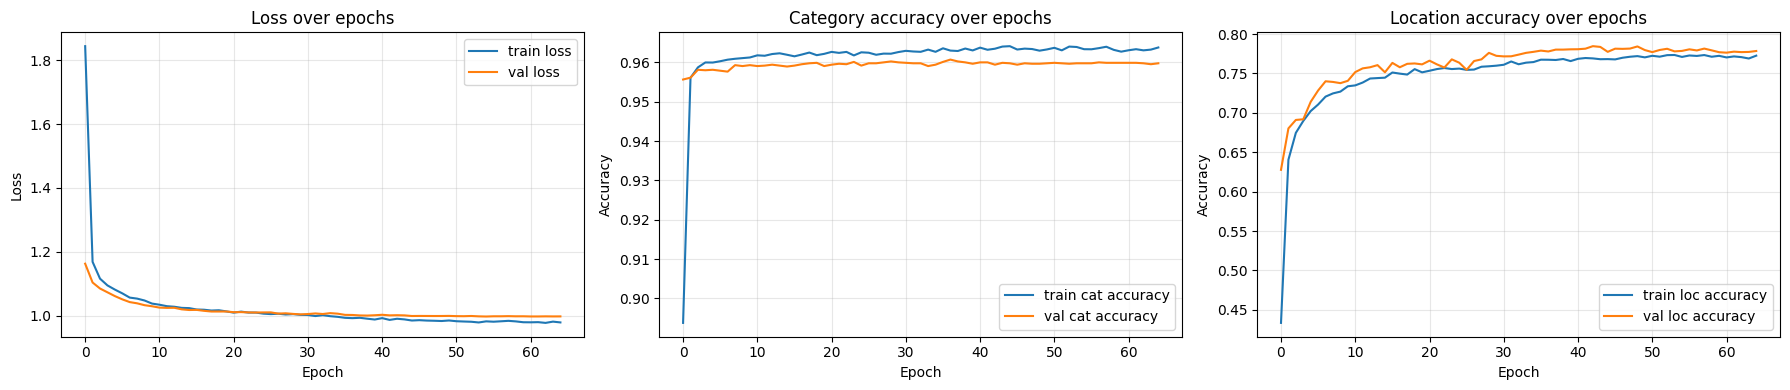

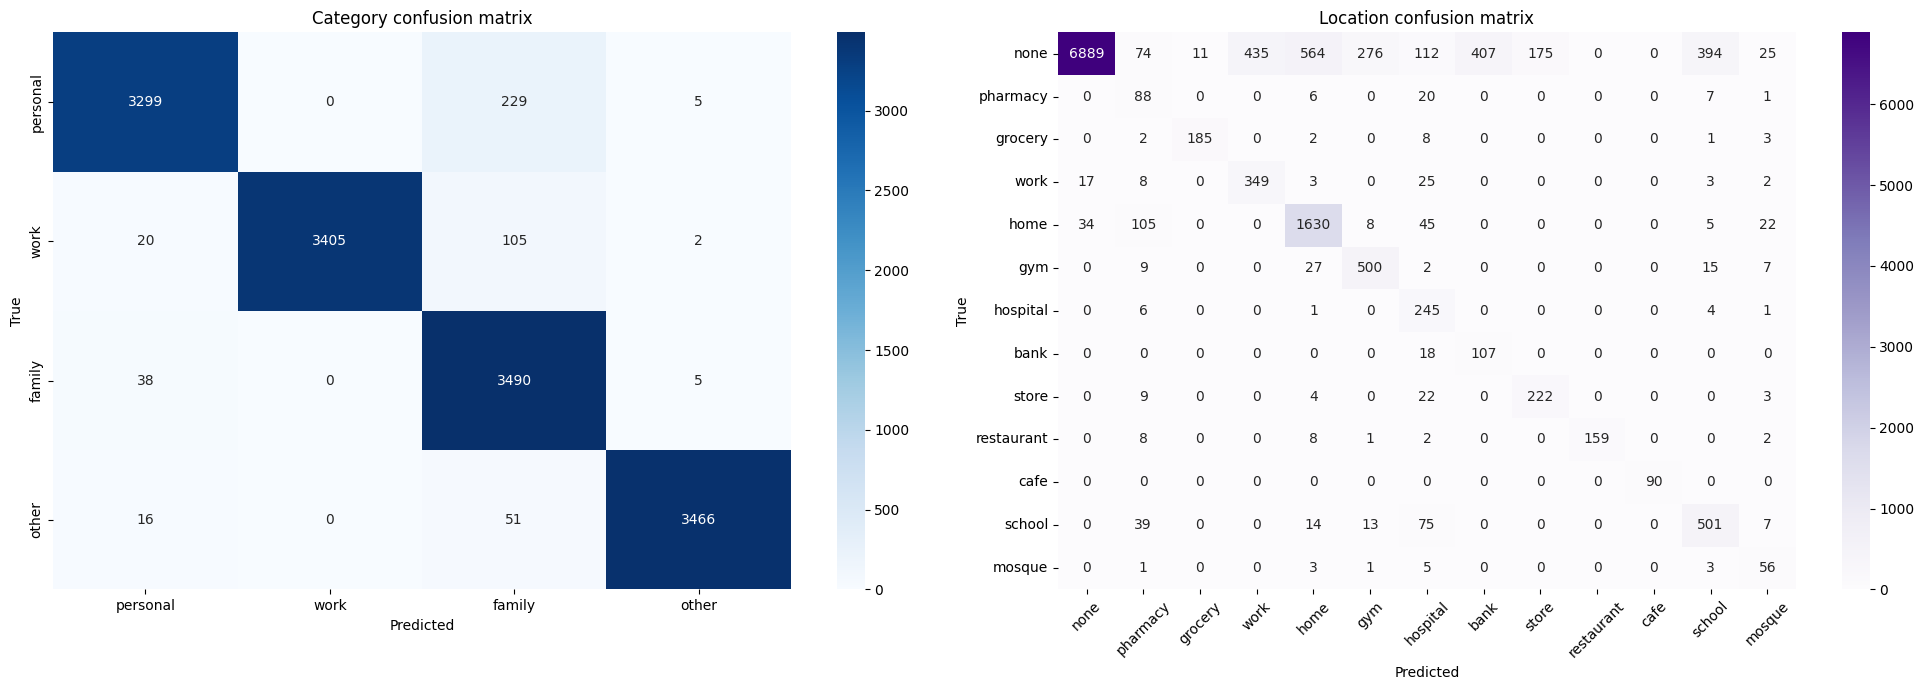


عدد أخطاء الفئة: 471 من 14131
عدد أخطاء الموقع: 3110 من 14131

أمثلة أخطاء الفئة:
true=personal pred=family   confidence=75.62%
true=personal pred=family   confidence=54.01%
true=other    pred=family   confidence=51.99%
true=personal pred=family   confidence=55.54%
true=work     pred=family   confidence=64.82%
true=personal pred=family   confidence=40.31%
true=personal pred=family   confidence=68.40%
true=family   pred=personal confidence=41.50%
true=work     pred=family   confidence=48.16%
true=personal pred=family   confidence=48.89%

أمثلة أخطاء الموقع:
true=none         pred=home         confidence=85.34%
true=home         pred=hospital     confidence=20.08%
true=none         pred=bank         confidence=91.30%
true=none         pred=school       confidence=75.19%
true=none         pred=store        confidence=84.75%
true=school       pred=hospital     confidence=25.98%
true=none         pred=bank         confidence=89.80%
true=home         pred=pharmacy     confidence=25.59%
true

In [8]:
# تقييم النموذج بعد التدريب وعرض الخطأ والدقة و F1 والرسوم ومصفوفات الالتباس
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns

results = model.evaluate(
    X_test,
    [Y_cat_test, Y_loc_test],
    verbose=0,
    return_dict=True,
)

print("نتائج الاختبار النهائية:")
for name, value in results.items():
    print(f"{name}: {value:.4f}")

cat_prob, loc_prob = model.predict(X_test, verbose=0)
y_cat_true = np.argmax(Y_cat_test, axis=1)
y_loc_true = np.argmax(Y_loc_test, axis=1)
y_cat_pred = np.argmax(cat_prob, axis=1)
y_loc_pred = np.argmax(loc_prob, axis=1)

cat_acc = accuracy_score(y_cat_true, y_cat_pred)
loc_acc = accuracy_score(y_loc_true, y_loc_pred)
cat_f1_macro = f1_score(y_cat_true, y_cat_pred, average="macro")
loc_f1_macro = f1_score(y_loc_true, y_loc_pred, average="macro")
cat_f1_weighted = f1_score(y_cat_true, y_cat_pred, average="weighted")
loc_f1_weighted = f1_score(y_loc_true, y_loc_pred, average="weighted")

print("\nملخص الدقة و F1:")
print(f"Category accuracy       : {cat_acc:.2%}")
print(f"Category macro F1       : {cat_f1_macro:.2%}")
print(f"Category weighted F1    : {cat_f1_weighted:.2%}")
print(f"Location accuracy       : {loc_acc:.2%}")
print(f"Location macro F1       : {loc_f1_macro:.2%}")
print(f"Location weighted F1    : {loc_f1_weighted:.2%}")

print("\nتقرير تصنيف الفئات:")
print(classification_report(
    y_cat_true,
    y_cat_pred,
    target_names=CATEGORIES,
    digits=3,
    zero_division=0,
))

print("\nتقرير تصنيف المواقع:")
print(classification_report(
    y_loc_true,
    y_loc_pred,
    target_names=LOCATION_TYPES,
    digits=3,
    zero_division=0,
))

# رسم منحنيات التدريب لمعرفة تطور الخطأ والدقة عبر العصور
hist = history.history
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hist["loss"], label="train loss")
axes[0].plot(hist["val_loss"], label="val loss")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(hist["cat_accuracy"], label="train cat accuracy")
axes[1].plot(hist["val_cat_accuracy"], label="val cat accuracy")
axes[1].set_title("Category accuracy over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(hist["loc_accuracy"], label="train loc accuracy")
axes[2].plot(hist["val_loc_accuracy"], label="val loc accuracy")
axes[2].set_title("Location accuracy over epochs")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# رسم مصفوفات الالتباس لمعرفة أين يخطئ النموذج في الفئات والمواقع
cat_cm = confusion_matrix(y_cat_true, y_cat_pred, labels=np.arange(len(CATEGORIES)))
loc_cm = confusion_matrix(y_loc_true, y_loc_pred, labels=np.arange(len(LOCATION_TYPES)))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(cat_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CATEGORIES, yticklabels=CATEGORIES, ax=axes[0])
axes[0].set_title("Category confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(loc_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=LOCATION_TYPES, yticklabels=LOCATION_TYPES, ax=axes[1])
axes[1].set_title("Location confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

# عرض أمثلة من الأخطاء لمراجعة الحالات التي لم يتوقعها النموذج بشكل صحيح
cat_errors = np.where(y_cat_true != y_cat_pred)[0]
loc_errors = np.where(y_loc_true != y_loc_pred)[0]

print(f"\nعدد أخطاء الفئة: {len(cat_errors)} من {len(y_cat_true)}")
print(f"عدد أخطاء الموقع: {len(loc_errors)} من {len(y_loc_true)}")

print("\nأمثلة أخطاء الفئة:")
for i in cat_errors[:10]:
    print(f"true={CATEGORIES[y_cat_true[i]]:8s} pred={CATEGORIES[y_cat_pred[i]]:8s} confidence={cat_prob[i, y_cat_pred[i]]:.2%}")

print("\nأمثلة أخطاء الموقع:")
for i in loc_errors[:10]:
    print(f"true={LOCATION_TYPES[y_loc_true[i]]:12s} pred={LOCATION_TYPES[y_loc_pred[i]]:12s} confidence={loc_prob[i, y_loc_pred[i]]:.2%}")

In [9]:
# اختبار النموذج على أمثلة جديدة وقراءة التوقعات النهائية للفئة والموقع
TEST_EXAMPLES = [
    (0, 8.0, "team meeting"),
    (1, 19.0, "go to the gym"),
    (2, 10.0, "buy groceries"),
    (3, 18.5, "dinner with family"),
    (4, 9.0, "موعد الطبيب"),
    (5, 12.5, "صلاة الجمعة"),
    (6, 20.0, "كافيه مع صديق"),
    (0, 7.0, "الذهاب للجامعة"),
]

def predict_habit(day, hour, title):
    x = np.array([encode_features(day, hour, title)], dtype=np.float32)
    cat_prob, loc_prob = model.predict(x, verbose=0)
    cat_idx = int(np.argmax(cat_prob[0]))
    loc_idx = int(np.argmax(loc_prob[0]))
    return {
        "title": title,
        "day": day,
        "hour": hour,
        "category": CATEGORIES[cat_idx],
        "category_confidence": float(cat_prob[0][cat_idx]),
        "location": LOCATION_TYPES[loc_idx],
        "location_confidence": float(loc_prob[0][loc_idx]),
    }

print("اختبار النموذج على أمثلة جديدة:")
for day, hour, title in TEST_EXAMPLES:
    pred = predict_habit(day, hour, title)
    print(
        f"{pred['title']:<25s} | "
        f"day={pred['day']} hour={pred['hour']:>4.1f} | "
        f"category={pred['category']:<8s} ({pred['category_confidence']:.2%}) | "
        f"location={pred['location']:<12s} ({pred['location_confidence']:.2%})"
    )

اختبار النموذج على أمثلة جديدة:
team meeting              | day=0 hour= 8.0 | category=work     (96.73%) | location=work         (85.72%)
go to the gym             | day=1 hour=19.0 | category=personal (96.29%) | location=gym          (91.10%)
buy groceries             | day=2 hour=10.0 | category=other    (97.17%) | location=grocery      (96.55%)
dinner with family        | day=3 hour=18.5 | category=family   (96.68%) | location=home         (95.95%)
موعد الطبيب               | day=4 hour= 9.0 | category=personal (36.64%) | location=hospital     (32.35%)
صلاة الجمعة               | day=5 hour=12.5 | category=other    (55.61%) | location=mosque       (86.27%)
كافيه مع صديق             | day=6 hour=20.0 | category=other    (96.29%) | location=cafe         (96.52%)
الذهاب للجامعة            | day=0 hour= 7.0 | category=family   (39.79%) | location=school       (50.13%)
